# Importation

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pyoperators import (
    MPI,
    BlockDiagonalOperator,
    BlockRowOperator,
    DenseOperator,
    DiagonalOperator,
    ReshapeOperator,
    PackOperator
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from scipy.optimize import minimize

from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.Instrument.Qnoise import QubicTotNoise
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing
from qubic.lib.Qscene import QubicScene

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

# Scanning Strategy

## Galactic Coordinates

In [4]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["period"] = 3

### Sweepingpointing
qubic_dict["sweeping_pointing"] = False
qubic_dict["fix_azimuth"]["apply"] = False

# qubic_dict['angspeed'] = 0.4
# qubic_dict['delta_az'] = 20
# qubic_dict['nsweeps_per_elevation'] = 5
# qubic_dict['period'] = 1e-15
# qubic_dict['duration'] = 1
# npointings = 3600 * t_obs / period

### Repeat pointing
qubic_dict["repeat_pointing"] = False

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array(
    [np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)]
)
# print(q_sampling_gal)

In [5]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

# fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# # Azimuth plot
# axs[0].plot(az)
# axs[0].set_title("Azimuth")
# axs[0].set_xlabel("Time samples")
# axs[0].set_ylabel("Angles (degrees)")

# # Elevation plot
# axs[1].plot(el)
# axs[1].set_title("Elevation")
# axs[1].set_xlabel("Time samples")
# axs[1].set_ylabel("Angles (degrees)")

# # Scanning strategy plot
# axs[2].plot(az, el)
# axs[2].set_title("Scanning strategy")
# axs[2].set_xlabel("Azimuth (degrees)")
# axs[2].set_ylabel("Elevation (degrees)")

# # Equatorial coordinates plot
# axs[3].plot(
#     (q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1]
# )
# axs[3].set_title("Equatorial coordinates")
# axs[3].set_xlabel("Right ascension (degrees)")
# axs[3].set_ylabel("Declination (degrees)")

# # Galactic coordinates plot
# axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
# axs[4].set_title("Galactic coordinates")
# axs[4].set_xlabel("Longitude (degrees)")
# axs[4].set_ylabel("Latitude (degrees)")

# fig.suptitle("Qubic Sampling")
# plt.tight_layout()
# plt.show()

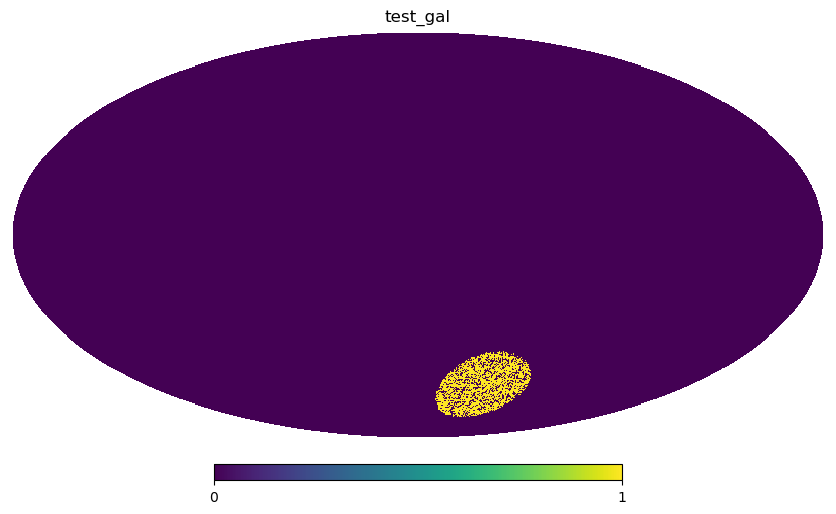

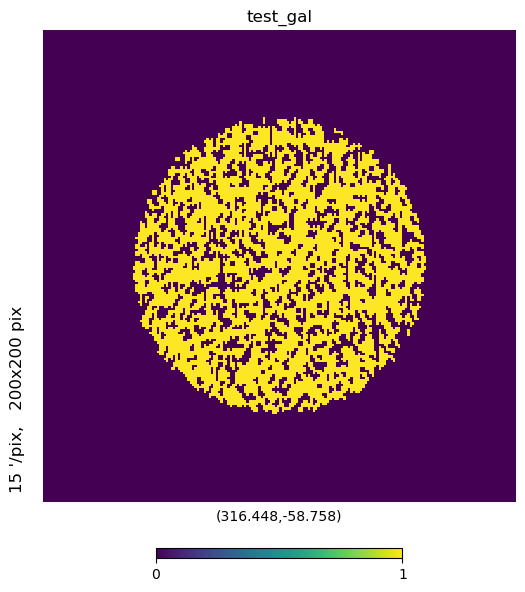

In [6]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Local Coordinates

In [7]:
### Define scanning strategy for atm observation
q_sampling_local = QubicSampling(
    q_sampling_gal.index.size,
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local.azimuth = q_sampling_gal.azimuth
q_sampling_local.elevation = q_sampling_gal.elevation
q_sampling_local.pitch = q_sampling_gal.pitch
q_sampling_local.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local.fix_az = True

In [8]:
# test_gal = np.zeros(hp.nside2npix(params["nside"]))

# index = np.array(
#     Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
#         np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
#     ),
#     dtype="int",
# )
# test_gal[index] = 1
# hp.mollview(test_gal, title="test_local", cmap="viridis")
# hp.gnomview(
#     test_gal,
#     title="test_local",
#     cmap="viridis",
#     reso=15,
#     rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
# )

# print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

# Input Maps

## CMB

In [9]:
# Build CMB map
cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
cmb_map = hp.synfast(cl_cmb, params["nside"], new=True, verbose=False).T

cmb_maps = np.ones((params["nsub_in"], hp.nside2npix(params["nside"]), 3))
cmb_maps *= cmb_map[None]
print(cmb_maps.shape)

# hp.mollview(cmb_map[:, 0], cmap="jet", title="CMB map", unit=r"$µK_{CMB}$")

(8, 196608, 3)


## Atmosphere

In [10]:
atm_maps = np.zeros((cmb_maps.shape))
atm_maps[..., 0] = atm.get_temp_maps(atm.delta_rho_map) / 1e3
print(atm_maps.shape)

(8, 196608, 3)


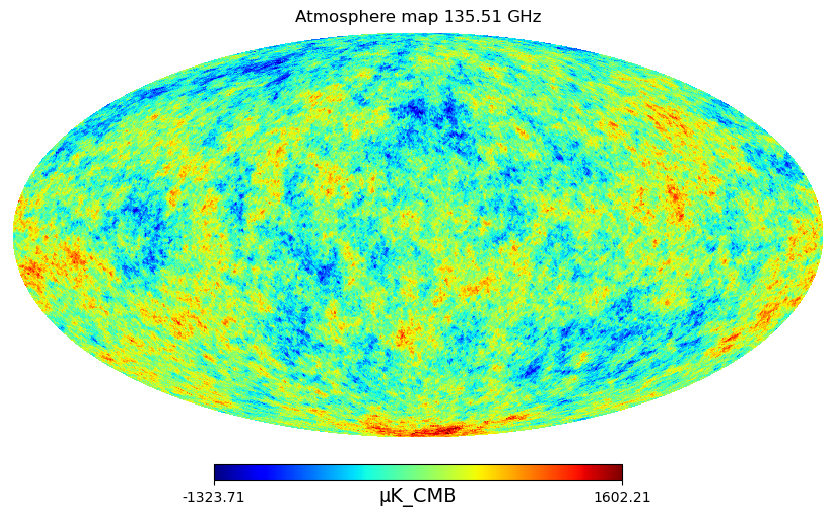

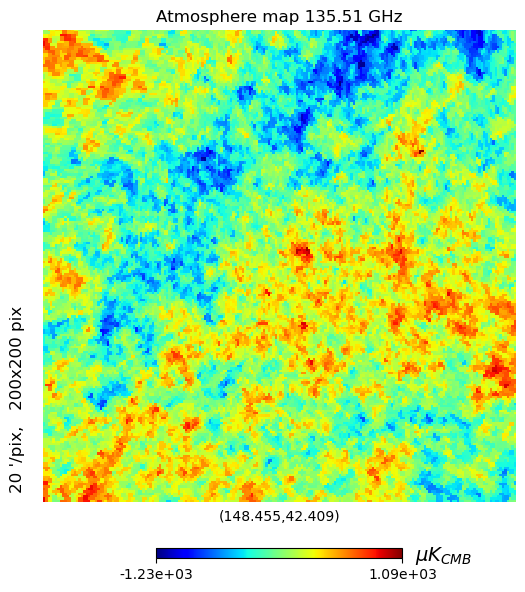

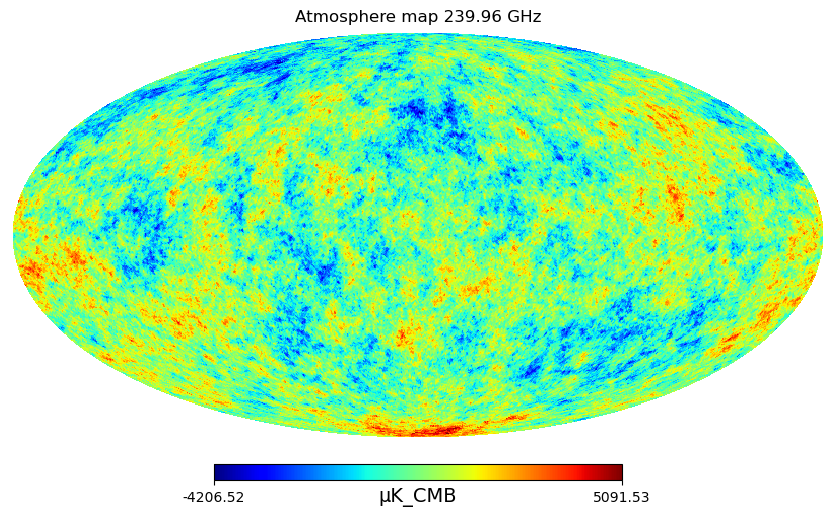

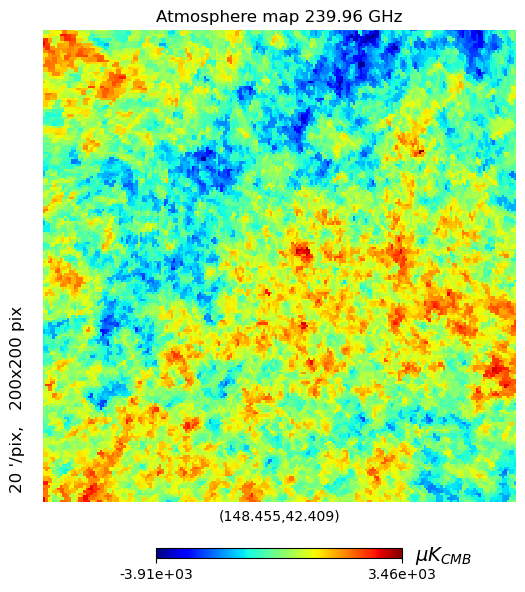

In [11]:
index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

## Apply convolutions - Input Maps

In [12]:
# fwhm_synthbeam150 = 0.006853589624526168

# _, _, filter_nus150, deltas150, _, _ = compute_freq(
#     150,
#     int(params["nsub_in"] / 2),
#     relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
#     frequency_spacing="log",
# )
# _, _, filter_nus220, deltas220, _, _ = compute_freq(
#     220,
#     int(params["nsub_in"] / 2),
#     relative_bandwidth=qubic_dict["filter_relative_bandwidth"],
#     frequency_spacing="log",
# )

# nus_tod = np.concatenate((filter_nus150, filter_nus220)) * 1e9
# fwhm_tod = fwhm_synthbeam150 * 150e9 / nus_tod

In [13]:
# for isub in range(nus_tod.size):
#     C = HealpixConvolutionGaussianOperator(fwhm=fwhm_tod[isub])
#     atm_maps[isub] = C(atm_maps[isub])
#     cmb_maps[isub] = C(cmb_maps[isub])

## Input Maps

In [14]:
input_maps = np.zeros((2 * params["nsub_in"], hp.nside2npix(params["nside"]), 3))

input_maps[: params["nsub_in"]] = cmb_maps
input_maps[params["nsub_in"] :] = atm_maps

## True maps

In [15]:
### Build Expected Atm Maps
true_maps = np.zeros((2, 12 * params["nside"] ** 2, 3))

# Build the reconstructed maps and frequency by taking the mean inside each reconstructed frequency band
# C = HealpixConvolutionGaussianOperator(fwhm=np.mean(fwhm_tod))
true_maps[0] = cmb_map
true_maps[1] = np.mean(atm_maps, axis=0)
# true_maps[0] = C(cmb_map)
# true_maps[1] = C(np.mean(atm_maps, axis=0))

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

# Mixing Matrix

(8, 2)


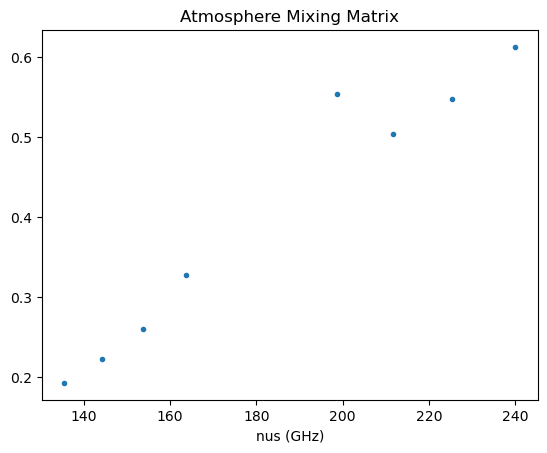

In [16]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix
mixing_matrix[:, 1] = (
    atm.temperature * atm.integrated_abs_spectrum * atm.mean_water_vapor_density
)
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Build QUBIC Instances

In [17]:
q_acquisition_local = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local
)

q_acquisition_gal = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_gal
)

qubic_scene = QubicScene(qubic_dict)
qubic_noise = QubicTotNoise(qubic_dict, q_sampling_gal, qubic_scene)

Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allocating (3968000,9) elements = 544.921875 MiB in FSRRotation3dMatrix.__init__.
Info apcnb2325: Allo

In [18]:
coverage_gal = q_acquisition_gal.coverage
covnorm_gal = coverage_gal / coverage_gal.max()
seenpix_gal = covnorm_gal > params["coverage_cut"]
seenpix_gal_wo_cut = covnorm_gal > 0

coverage_local = q_acquisition_local.coverage
covnorm_local = coverage_local / coverage_local.max()
seenpix_local = covnorm_local > params["coverage_cut"]
seenpix_local_wo_cut = covnorm_local > 0

seenpix = np.array([seenpix_gal, seenpix_local])

# Build QUBIC Operaotors

In [19]:
# Galactic Coordinates

H_gal = q_acquisition_gal.get_operator()
print("H_gal :", H_gal.shapein, H_gal.shapeout)
invN_gal = q_acquisition_gal.get_invntt_operator(1, 1, 1)
print("invN_gal :", invN_gal.shapein, invN_gal.shapeout)

H_gal : (8, 196608, 3) (3968000,)
invN_gal : (992, 4000) (992, 4000)


In [20]:
# Local Coordinates

H_local = q_acquisition_local.get_operator()

invN_local = q_acquisition_local.get_invntt_operator(1, 1, 1)

In [21]:
### Full MM
R = ReshapeOperator((2 * 992, params["npointings"]), (params["npointings"] * 992 * 2))

r = ReshapeOperator((npix, 3), (1, npix, 3))
A_gal = (
    DenseOperator(
        mixing_matrix[:, 0, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)
A_local = (
    DenseOperator(
        mixing_matrix[:, 1, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
    * r
)

H = BlockRowOperator([H_gal(A_gal), H_local(A_local)], axisin=0) * ReshapeOperator(
    (2, npix, 3), (2 * npix, 3)
)

R = ReshapeOperator(invN_gal.shapein, H.shapeout)
invN = R(invN_gal(R.T))

tod = H(true_maps) + qubic_noise.total_noise(1, 1, 1, seed_noise=params["seed"]).ravel()
print(tod.shape)

Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs
(3968000,)


# Map-Making

In [22]:
# preconditioner

ncomp = 2
nside = params["nside"]
npix = 12 * nside**2
nsub = params["nsub_in"]
no_det = 992

stacked_dptdp_inv = np.empty((ncomp, npix))

q_acq = [q_acquisition_gal, q_acquisition_local]


for icomp in range(ncomp):
    H_qubic = q_acq[icomp].operator

    stacked_dptdp_inv_nsub = np.empty((nsub, npix))

    for j_nsub in range(nsub):
        H_single = H_qubic[j_nsub]

        D = H_single.operands[1]
        P = H_single.operands[4]
        sh = P.matrix.data.index.shape

        point_per_det = sh[0] // no_det
        mapPtP_perdet_seq = np.empty((no_det, npix))

        for det in range(no_det):
            start, end = det * point_per_det, (det + 1) * point_per_det
            indices = P.matrix.data.index[start:end, :]
            weights = P.matrix.data.r11[start:end, :]
            flat_indices = indices.ravel()
            flat_weights = weights.ravel()

            mapPitPi = np.bincount(
                flat_indices, weights=flat_weights**2, minlength=npix
            )
            mapPtP_perdet_seq[det, :] = mapPitPi

        D_sq = D.data**2
        mapPtP_seq_scaled = D_sq[:, np.newaxis] * mapPtP_perdet_seq
        dptdp = mapPtP_seq_scaled.sum(axis=0)

        # Safe inversion
        dptdp_inv = np.zeros_like(dptdp)
        nonzero = dptdp != 0
        dptdp_inv[nonzero] = 1.0 / dptdp[nonzero]
        stacked_dptdp_inv_nsub[j_nsub] = dptdp_inv

    stacked_dptdp_inv[icomp] = stacked_dptdp_inv_nsub.sum(axis=0)

preconditioner = BlockDiagonalOperator(
    [DiagonalOperator(ci, broadcast="rightward") for ci in stacked_dptdp_inv],
    new_axisin=0,
)

In [23]:
# I start from an atm map for the CMB and from a cmb map for the atmosphere
maps_rec = true_maps.copy()
for i in range(2):
    error_I = 2 * np.std(maps_rec[i, ..., 0])
    maps_rec[i, ..., 0] += np.random.uniform(
        -error_I, error_I, true_maps[i, ..., 0].shape
    )

maps_rec *= 0

mixing_matrix_rec = np.ones_like(mixing_matrix)

seenpix = np.array([seenpix_gal, seenpix_local])

# Map-Making library

In [24]:
def get_H(Amm):
    A_local = (
        DenseOperator(
            Amm[:, 1, None],
            broadcast="rightward",
            shapein=(1, npix, 3),
            shapeout=(params["nsub_in"], npix, 3),
        )
        * r
    )
    H =  BlockRowOperator(
        [H_gal(A_gal), H_local(A_local)], axisin=0
    ) * ReshapeOperator((2, npix, 3), (2 * npix, 3))
    return H

def get_tod_comp(H):
    tod_comp = np.zeros((2, nsub, 992*params["npointings"]))
    for icomp in range(2):
        for jnus in range(nsub):
            tod_comp[icomp, jnus] = H.operands[0].operands[icomp].operands[1].operands[jnus](maps_rec[icomp]).ravel()
    return tod_comp
    

def call_pcg(A, b, x0, max_iter=5):
    algo = PCGAlgorithm(
        A,
        b,
        comm,
        x0=x0,
        tol=1e-12,
        maxiter=max_iter,
        disp=True,
        M=None,
        center=[0, -57],
        reso=15,
        seenpix=seenpix,
        input=true_maps,
    )
    try:
        result = algo.run()
        success = True
        message = "Success"
    except AbnormalStopIteration as e:
        result = algo.finalize()
        success = False
        message = str(e)

    return result

In [25]:
def get_chi2(x, tod_comp):
    mm = np.empty(mixing_matrix_rec.shape)
    mm[:, 0] = mixing_matrix_rec[:, 0]
    mm[:, 1] = x
    tod_sim = np.einsum('ij,jik->k', mm, tod_comp)
    
    res = tod - tod_sim
    chi2 = 0.5 * (np.dot(res.T, invN(res)))
    return chi2


def fit_mm(mixing_matrix, tod_comp):
    chi2 = get_chi2

    Ai = minimize(
        chi2,
        x0=mixing_matrix[:, 1],
        method="L-BFGS-B",
        # tol=1e-10,
        args=tod_comp
    ).x
    return Ai

# Run Map-Making

In [26]:
# Fix CMB Intensity + Atm Polarisation
mask = np.ones((2, npix, 3))              # Mask for 2 components : CMB & Atm
mask[0, :, 0] = 0                               # CMB Intensity
mask[1, :, [1,2]] = 0                           # Atm Polarisation
P = PackOperator(mask).T                        # Build Mask Operator
x_masked = true_maps * (1-mask)

In [27]:
max_iter = 25
n_loop = 50
x = P.T(maps_rec * 0)

In [28]:
# Run PCG
convergence = []

# Reconstruction loop
for iloop in range(n_loop):
    print("=====================================")
    print("Iteration : ", iloop) 
    print("-------------------------------------")
    
    ### fit pixels
    print("Fit Maps :")
    print("-------------------------------------")
    H = get_H(mixing_matrix_rec)
    A = P.T * H.T * invN * H * P
    b = P.T * H.T * invN * (H(true_maps) - H(x_masked))
    result = call_pcg(A, b, x, iloop)
    output = result["x"].copy()
    print("Previous Maps: ", maps_rec[seenpix].mean(axis=0))
    maps_rec[0, :, 1:] = output[: npix * 2].reshape(npix, 2)     # Update CMB Pol
    maps_rec[1, :, 0] = output[npix*2:]                          # Update Atm Intensity
    convergence.append(result["convergence"])
    print("Next Maps: ", maps_rec[seenpix].mean(axis=0))
    print("Residual Maps: ", (true_maps-maps_rec)[seenpix].mean(axis=0))
    x = P.T(maps_rec)

    ### fit mixing matrix
    print("-------------------------------------")
    print("Previous MM: ", mixing_matrix_rec[:, 1])
    tod_comp = get_tod_comp(H)
    mixing_matrix_rec[:, 1] = fit_mm(mixing_matrix_rec, tod_comp)
    print("Next MM : ", mixing_matrix_rec[:, 1])
    print("Residual : ", (mixing_matrix - mixing_matrix_rec)[:, 1])
    print("=====================================")

Iteration :  0
-------------------------------------
Fit Maps :
-------------------------------------
Previous Maps:  [0. 0. 0.]
Next Maps:  [0. 0. 0.]
Residual Maps:  [-1.49587731e+01 -6.28481532e-02 -2.13529882e-05]
-------------------------------------
Previous MM:  [1. 1. 1. 1. 1. 1. 1. 1.]
Next MM :  [1. 1. 1. 1. 1. 1. 1. 1.]
Residual :  [-0.80730746 -0.77714279 -0.73962071 -0.67249383 -0.44693764 -0.49608105
 -0.45260403 -0.38765898]
Iteration :  1
-------------------------------------
Fit Maps :
-------------------------------------
 Iter     Tol      time
   1: 3.1183e-01 3.28527 [0. 0. 0. 0. 0. 0.]
Previous Maps:  [0. 0. 0.]
Next Maps:  [29.3563987   0.08711244 -0.08204522]
Residual Maps:  [-44.31517177  -0.14996059   0.08202387]
-------------------------------------
Previous MM:  [1. 1. 1. 1. 1. 1. 1. 1.]
Next MM :  [ 0.02299301 -0.41801247 -0.021478    1.597692   -1.05162521  2.28655335
  2.44425706 -1.56926377]
Residual :  [ 0.16969952  0.64086968  0.28185729 -1.27018583  1

# PCG Plots

In [29]:
print(convergence[-1][-1])

2.3804474466718553e-05


Text(0, 0.5, 'Convergence')

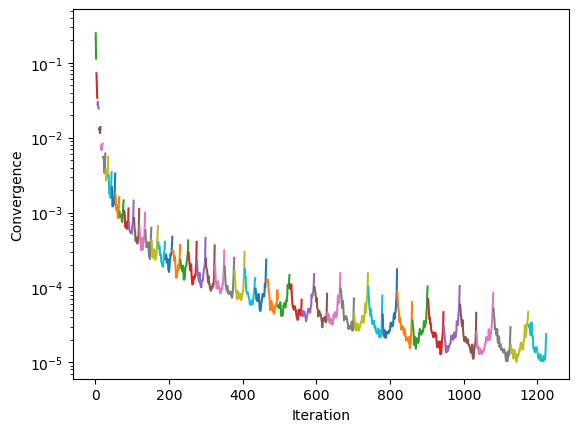

In [30]:
offset = 0

for iloop in range(n_loop):
    arr = np.arange(offset, offset + iloop)
    offset += iloop
    plt.plot(arr, convergence[iloop])
    # plt.vlines(arr[iloop][-1], np.min(convergence[iloop]), np.max(convergence[iloop]), "k", "--")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel(ylabel="Convergence")


In [31]:
# conv = np.concatenate(np.array(convergence))
# for i_loop in range(n_loop):
#     plt.plot(i_loop)
#     plt.vlines(max_iter* i_loop, np.min(conv), np.max(conv), "k", "--")
# plt.plot(conv)
# plt.yscale("log")
# plt.xlabel("Iteration")
# plt.ylabel(ylabel="Convergence")

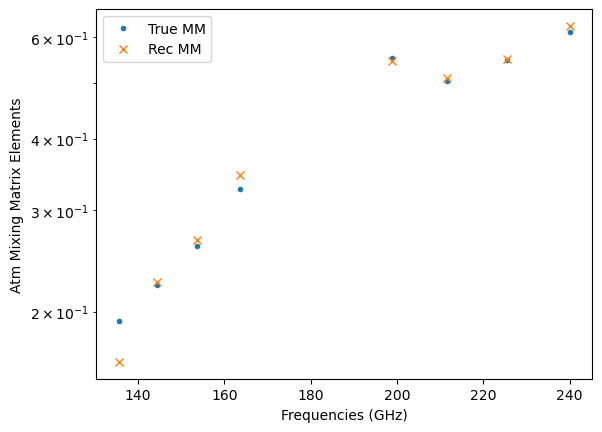

In [32]:
plt.plot(atm.frequencies, mixing_matrix[:, 1], ".",label="True MM")
plt.plot(atm.frequencies, mixing_matrix_rec[:, 1], "x", label="Rec MM")
plt.legend()
plt.xlabel("Frequencies (GHz)")
plt.ylabel("Atm Mixing Matrix Elements")
plt.yscale("log")

In [33]:
input = true_maps.copy()
output = maps_rec
residual = output - input

# Maps Plots

In [34]:
input_cmb = input[0, :, 1:]
input_atm = input[1, : , :1]

output_cmb = output[0, :, 1:]
output_atm = output[1, : , :1]

residual_cmb = residual[0, :, 1:]
residual_atm = residual[1, : , :1]

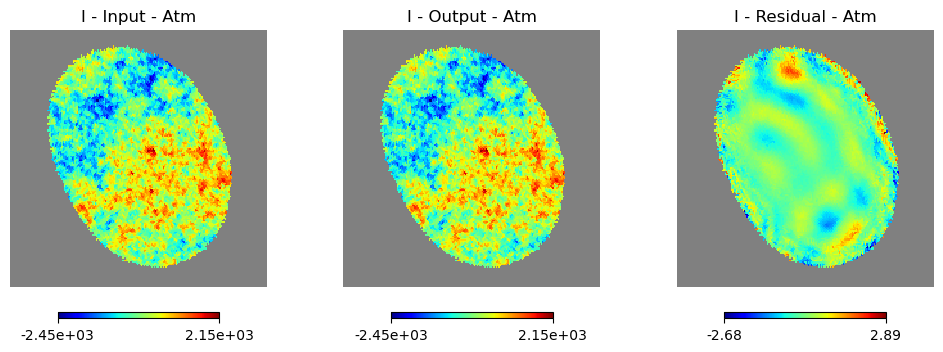

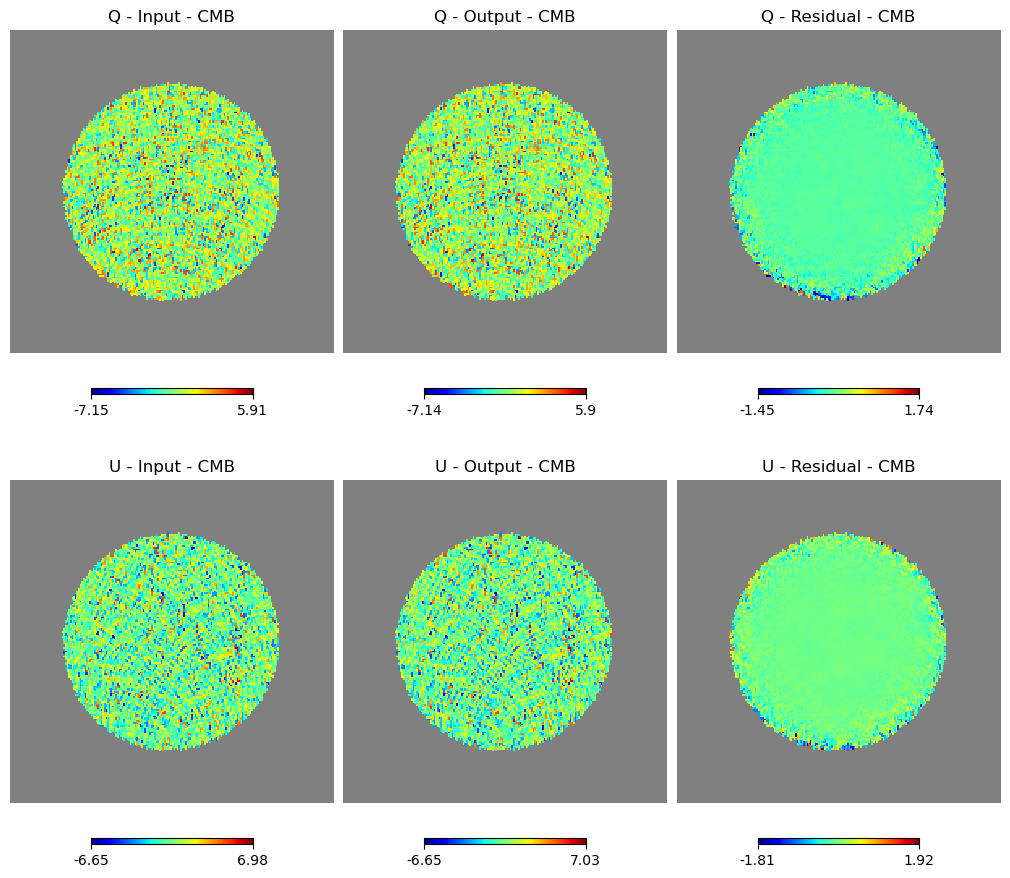

In [46]:
# For Q/U only (istk = 0: Q, istk = 1: U)
stk = ["Q", "U"]
reso = 20

# ATMOSPHERE (I)
plt.figure(figsize=(10, 10))
atm_stk = ["I", "Q", "U"]
for istk in range(input_atm.shape[-1]):
    hp.gnomview(
        input_atm[:, istk],
        reso=reso,
        rot=center_local,
        cmap="jet",
        sub=(3, 3, istk*3 + 1),
        title=f"{atm_stk[istk]} - Input - Atm",
        notext=True,
    )
    hp.gnomview(
        output_atm[:, istk],
        reso=reso,
        rot=center_local,
        cmap="jet",
        sub=(3, 3, istk*3 + 2),
        title=f"{atm_stk[istk]} - Output - Atm",
        notext=True,
    )
    hp.gnomview(
        residual_atm[:, istk],
        reso=reso,
        rot=center_local,
        cmap="jet",
        sub=(3, 3, istk*3 + 3),
        title=f"{atm_stk[istk]} - Residual - Atm",
        notext=True,
    )
plt.tight_layout()

# CMB (Q, U)
plt.figure(figsize=(10, 9))
for istk in range(len(stk)):
    hp.gnomview(
        input_cmb[:, istk],
        reso=reso,
        rot=center_gal,
        cmap="jet",
        sub=(len(stk), 3, istk * 3 + 1),
        title=f"{stk[istk]} - Input - CMB",
        notext=True,
    )
    hp.gnomview(
        output_cmb[:, istk],
        reso=reso,
        rot=center_gal,
        cmap="jet",
        sub=(len(stk), 3, istk * 3 + 2),
        title=f"{stk[istk]} - Output - CMB",
        notext=True,
    )
    hp.gnomview(
        residual_cmb[:, istk],
        reso=reso,
        rot=center_gal,
        cmap="jet",
        sub=(len(stk), 3, istk * 3 + 3),
        title=f"{stk[istk]} - Residual - CMB",
        notext=True,
    )
plt.tight_layout()